In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import gcf
from matplotlib import cm, colors
import os
from joblib import Parallel, delayed
import pickle
import numpy as np
from tqdm import tqdm
import multiprocessing
import warnings

import scipy.stats as stats 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm  # Progress bar for Jupyter

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


pd.set_option('display.max_columns', None)

In [2]:
revised_dir = "/hcc_predict_revised"
os.chdir(revised_dir)
df_baseline = pd.read_csv('base_hcv_induced_persistant_22122025.csv', index_col=0)

In [3]:
df_baseline.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark,Reactome,same_direction,log2FoldChange_hcv,hcv_sig,log2FoldChange_fu,padj_fu,fu_sig
Geneid,,,,,,,,,,,,,,,,
ENSG00000173702,362.609388,2.012033,0.473098,4.252890,0.000021,0.006900,2.012033,MUC13,NaN,NaN,False,3.862532,True,-0.793915,0.340126,False
ENSG00000186487,6.203493,-1.827540,0.568039,-3.217281,0.001294,0.029632,1.827540,MYT1L,NaN,NaN,False,-2.486947,True,NaN,NaN,False
ENSG00000077279,13.838431,1.457836,0.501861,2.904861,0.003674,0.048131,1.457836,DCX,['HALLMARK_PANCREAS_BETA_CELLS'],NaN,False,2.300463,True,-0.380040,0.728455,False
ENSG00000158014,28.562048,1.376624,0.367305,3.747908,0.000178,0.014595,1.376624,SLC30A2,NaN,NaN,False,1.640211,True,-1.045740,0.099286,False
ENSG00000175879,9.171516,1.317220,0.332579,3.960625,0.000075,0.010085,1.317220,HOXD8,NaN,NaN,False,2.764809,True,-0.515155,0.477113,False


In [4]:
# Load the data
raw = pd.read_csv('counts_baseline.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info excpet length
raw = raw.iloc[:,4:]
# Change column names
raw.columns = raw.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')

In [5]:
def calculate_tpm(df, length_col="Length"):
    """
    Calculate TPM values for a gene expression dataframe.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing raw counts and a gene length column.
        Rows = genes, Columns = samples + one length column.
    length_col : str, default "Length"
        Name of the column containing gene lengths (in base pairs).

    Returns
    -------
    tpm_df : pandas.DataFrame
        DataFrame of TPM-normalized counts (same shape as count columns).
    """

    # Copy to avoid modifying original
    df = df.copy()

    # Extract lengths and convert to kilobases
    lengths_kb = df[length_col] / 1000.0

    # Identify count columns (all except length_col)
    count_cols = [c for c in df.columns if c != length_col]

    # Step 1: RPK = counts / gene_length_kb
    rpk = df[count_cols].div(lengths_kb, axis=0)

    # Step 2: per-sample scaling factor = sum(RPK)
    scaling_factors = rpk.sum(axis=0) / 1e6   # per-million scaling

    # Step 3: TPM = RPK / scaling_factor
    tpm = rpk.div(scaling_factors, axis=1)

    return tpm

In [6]:
tpm = calculate_tpm(raw)
tpm.head()

,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,BSSE_QGF_225171,BSSE_QGF_225172,BSSE_QGF_225173,BSSE_QGF_225174,BSSE_QGF_225175,BSSE_QGF_225176,BSSE_QGF_225177,BSSE_QGF_225178,BSSE_QGF_225179,BSSE_QGF_225180,BSSE_QGF_225181,BSSE_QGF_225182,BSSE_QGF_225183,BSSE_QGF_225184,BSSE_QGF_225185,BSSE_QGF_225186,BSSE_QGF_225187,BSSE_QGF_225188,BSSE_QGF_225189,BSSE_QGF_225190,BSSE_QGF_225191,BSSE_QGF_225192,BSSE_QGF_225193,BSSE_QGF_225194,BSSE_QGF_225195,BSSE_QGF_225196,BSSE_QGF_225197,BSSE_QGF_225198,BSSE_QGF_225199,BSSE_QGF_225200,BSSE_QGF_225201,BSSE_QGF_225202,BSSE_QGF_225203,BSSE_QGF_225204,BSSE_QGF_225205,BSSE_QGF_225206,BSSE_QGF_225207,BSSE_QGF_225208,BSSE_QGF_225209,BSSE_QGF_225210,BSSE_QGF_225211,BSSE_QGF_225212,BSSE_QGF_225213,BSSE_QGF_225214,BSSE_QGF_225215,BSSE_QGF_225216,BSSE_QGF_225217,BSSE_QGF_225218
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,2.116619,1.822508,1.818296,1.237236,1.181366,2.054311,1.435909,1.741614,2.030522,2.678597,1.473035,1.717439,2.161894,2.514798,0.965076,1.969166,1.720229,2.473485,2.088051,2.103890,1.810692,1.710758,2.219320,1.575341,1.647403,1.179651,1.164197,1.192563,1.474563,1.220548,1.568608,1.602093,1.568920,1.358023,1.748393,1.831213,0.947679,1.050329,2.246710,2.597978,2.417834,1.768713,1.504735,3.300000,2.033075,1.219827,1.769714,1.278757,2.566531,1.845419,2.198707,3.325415
ENSG00000279928,0.547245,0.497303,0.339745,0.368915,0.192855,0.716840,0.348867,0.668732,0.427256,0.354540,0.390160,0.316056,0.129947,0.000000,0.000000,0.424164,0.350127,0.295814,0.247704,0.090061,0.244507,0.029727,0.085625,0.784425,0.231395,0.082134,0.410413,0.070840,0.211525,0.872551,0.069010,0.456171,0.175202,0.000000,0.114260,0.617312,0.604398,0.060785,0.157787,0.375172,0.156743,0.425888,0.000000,0.253117,0.366612,0.499445,0.184986,0.293748,0.184410,0.000000,0.116724,0.649140
ENSG00000228037,1.188231,1.169775,0.824941,0.522531,1.299458,1.398673,0.688259,1.683455,1.491301,1.896591,1.162662,1.151132,0.986019,2.283580,1.370059,1.158658,1.235373,1.144742,1.127727,1.189068,1.781072,1.190983,2.299963,0.742823,1.775859,0.972228,0.716255,0.709536,1.348216,1.260234,1.476651,0.830727,1.156585,0.586760,0.762952,1.887013,0.825495,1.079270,1.436719,2.220467,1.332066,1.789795,0.897170,0.921894,1.483626,1.364300,1.937034,1.123377,2.574672,0.986469,1.594230,2.955350
ENSG00000142611,0.142489,0.186228,0.125574,0.071766,0.121553,0.119528,0.074653,0.105603,0.245190,0.338813,0.068309,0.159298,0.187064,0.166977,0.147144,0.250842,0.217104,0.202848,0.118057,0.042048,0.085616,0.100622,0.179893,0.042117,0.150475,0.044738,0.095806,0.136430,0.075831,0.087796,0.122835,0.041835,0.076686,0.104987,0.066682,0.172411,0.062987,0.019511,0.405170,0.172423,0.250032,0.137657,0.102227,0.543603,0.406512,0.155453,0.196123,0.068572,0.114796,0.069154,0.422342,0.233130
ENSG00000284616,0.000000,0.000000,0.000000,0.019073,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027337,0.000000,0.000000,0.000000,0.000000


In [7]:
subset = tpm.loc[df_baseline.index,:].copy()
subset.head()

,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,BSSE_QGF_225171,BSSE_QGF_225172,BSSE_QGF_225173,BSSE_QGF_225174,BSSE_QGF_225175,BSSE_QGF_225176,BSSE_QGF_225177,BSSE_QGF_225178,BSSE_QGF_225179,BSSE_QGF_225180,BSSE_QGF_225181,BSSE_QGF_225182,BSSE_QGF_225183,BSSE_QGF_225184,BSSE_QGF_225185,BSSE_QGF_225186,BSSE_QGF_225187,BSSE_QGF_225188,BSSE_QGF_225189,BSSE_QGF_225190,BSSE_QGF_225191,BSSE_QGF_225192,BSSE_QGF_225193,BSSE_QGF_225194,BSSE_QGF_225195,BSSE_QGF_225196,BSSE_QGF_225197,BSSE_QGF_225198,BSSE_QGF_225199,BSSE_QGF_225200,BSSE_QGF_225201,BSSE_QGF_225202,BSSE_QGF_225203,BSSE_QGF_225204,BSSE_QGF_225205,BSSE_QGF_225206,BSSE_QGF_225207,BSSE_QGF_225208,BSSE_QGF_225209,BSSE_QGF_225210,BSSE_QGF_225211,BSSE_QGF_225212,BSSE_QGF_225213,BSSE_QGF_225214,BSSE_QGF_225215,BSSE_QGF_225216,BSSE_QGF_225217,BSSE_QGF_225218
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000173702,1.604668,1.579745,0.073794,0.333875,0.666035,0.550515,0.928251,0.102531,0.591613,0.736387,0.219566,1.914371,0.790303,7.894824,2.159661,1.888674,2.951666,7.734358,2.394215,0.132042,5.826714,1.510908,0.376611,0.265794,0.183091,0.071360,0.083572,0.438526,1.004209,1.382207,2.956624,2.653999,0.285411,4.019711,2.183975,0.100562,0.675145,0.039608,8.602302,0.137513,0.919225,0.010674,0.749052,5.904656,2.415439,21.728944,10.225776,2.866377,0.841151,0.485341,2.395855,2.245096
ENSG00000186487,0.011572,0.002010,0.016482,0.011268,0.000000,0.004140,0.023506,0.008906,0.003455,0.002150,0.004015,0.000000,0.004903,0.000571,0.000000,0.000000,0.002831,0.000000,0.001335,0.010194,0.001130,0.004807,0.003462,0.001015,0.001604,0.001771,0.002765,0.004582,0.004398,0.004865,0.000000,0.001054,0.000000,0.000868,0.000000,0.016400,0.003491,0.003440,0.003402,0.011375,0.001690,0.012184,0.004721,0.000000,0.001976,0.001077,0.000000,0.000950,0.001988,0.000000,0.003775,0.000000
ENSG00000077279,0.000000,0.023152,0.000000,0.000000,0.004310,0.000000,0.000000,0.000000,0.023869,0.044565,0.011889,0.104336,0.009679,0.122348,0.054525,0.028436,0.044010,0.012394,0.036902,0.000000,0.081958,0.016607,0.004783,0.003506,0.007387,0.003059,0.000000,0.011873,0.000000,0.045384,0.026987,0.025484,0.004894,0.051000,0.025533,0.004927,0.004824,0.000000,0.111656,0.000000,0.023351,0.007321,0.028542,0.050906,0.163849,0.089286,0.055117,0.032821,0.020604,0.003783,0.078251,0.058582
ENSG00000158014,0.158448,0.189898,0.037067,0.026833,0.227240,0.058656,0.076124,0.103002,0.198110,0.478675,0.104483,0.300935,0.028355,0.346841,0.106483,0.222129,0.229196,2.505244,0.283761,0.058955,0.160056,0.155677,0.070063,0.061619,0.064917,0.062727,0.055971,0.092745,0.039562,0.379145,0.056468,0.010665,0.071680,0.131823,0.162057,0.144320,0.056521,0.059685,0.258222,0.015349,0.136807,0.080420,0.035833,0.364523,0.106661,0.267002,0.227050,0.086531,0.100597,0.022162,0.171919,0.065374
ENSG00000175879,0.036508,0.000000,0.024554,0.000000,0.083627,0.044406,0.050426,0.068230,0.077195,0.192172,0.030761,0.037377,0.037565,0.153169,0.070536,0.024524,0.113868,0.160340,0.017902,0.000000,0.136317,0.090233,0.055693,0.040818,0.000000,0.023744,0.029661,0.107514,0.026206,0.091328,0.089773,0.021194,0.037986,0.104786,0.066061,0.038240,0.074881,0.013179,0.421926,0.000000,0.033984,0.056823,0.031649,0.109758,0.158972,0.303201,0.147060,0.025475,0.079965,0.058723,0.126536,0.389746


In [8]:
subset['Gene'] = subset.index.map(df_baseline.Gene)

In [9]:
subset.index = subset.Gene
subset.head()

,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,BSSE_QGF_225171,BSSE_QGF_225172,BSSE_QGF_225173,BSSE_QGF_225174,BSSE_QGF_225175,BSSE_QGF_225176,BSSE_QGF_225177,BSSE_QGF_225178,BSSE_QGF_225179,BSSE_QGF_225180,BSSE_QGF_225181,BSSE_QGF_225182,BSSE_QGF_225183,BSSE_QGF_225184,BSSE_QGF_225185,BSSE_QGF_225186,BSSE_QGF_225187,BSSE_QGF_225188,BSSE_QGF_225189,BSSE_QGF_225190,BSSE_QGF_225191,BSSE_QGF_225192,BSSE_QGF_225193,BSSE_QGF_225194,BSSE_QGF_225195,BSSE_QGF_225196,BSSE_QGF_225197,BSSE_QGF_225198,BSSE_QGF_225199,BSSE_QGF_225200,BSSE_QGF_225201,BSSE_QGF_225202,BSSE_QGF_225203,BSSE_QGF_225204,BSSE_QGF_225205,BSSE_QGF_225206,BSSE_QGF_225207,BSSE_QGF_225208,BSSE_QGF_225209,BSSE_QGF_225210,BSSE_QGF_225211,BSSE_QGF_225212,BSSE_QGF_225213,BSSE_QGF_225214,BSSE_QGF_225215,BSSE_QGF_225216,BSSE_QGF_225217,BSSE_QGF_225218,Gene
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MUC13,1.604668,1.579745,0.073794,0.333875,0.666035,0.550515,0.928251,0.102531,0.591613,0.736387,0.219566,1.914371,0.790303,7.894824,2.159661,1.888674,2.951666,7.734358,2.394215,0.132042,5.826714,1.510908,0.376611,0.265794,0.183091,0.071360,0.083572,0.438526,1.004209,1.382207,2.956624,2.653999,0.285411,4.019711,2.183975,0.100562,0.675145,0.039608,8.602302,0.137513,0.919225,0.010674,0.749052,5.904656,2.415439,21.728944,10.225776,2.866377,0.841151,0.485341,2.395855,2.245096,MUC13
MYT1L,0.011572,0.002010,0.016482,0.011268,0.000000,0.004140,0.023506,0.008906,0.003455,0.002150,0.004015,0.000000,0.004903,0.000571,0.000000,0.000000,0.002831,0.000000,0.001335,0.010194,0.001130,0.004807,0.003462,0.001015,0.001604,0.001771,0.002765,0.004582,0.004398,0.004865,0.000000,0.001054,0.000000,0.000868,0.000000,0.016400,0.003491,0.003440,0.003402,0.011375,0.001690,0.012184,0.004721,0.000000,0.001976,0.001077,0.000000,0.000950,0.001988,0.000000,0.003775,0.000000,MYT1L
DCX,0.000000,0.023152,0.000000,0.000000,0.004310,0.000000,0.000000,0.000000,0.023869,0.044565,0.011889,0.104336,0.009679,0.122348,0.054525,0.028436,0.044010,0.012394,0.036902,0.000000,0.081958,0.016607,0.004783,0.003506,0.007387,0.003059,0.000000,0.011873,0.000000,0.045384,0.026987,0.025484,0.004894,0.051000,0.025533,0.004927,0.004824,0.000000,0.111656,0.000000,0.023351,0.007321,0.028542,0.050906,0.163849,0.089286,0.055117,0.032821,0.020604,0.003783,0.078251,0.058582,DCX
SLC30A2,0.158448,0.189898,0.037067,0.026833,0.227240,0.058656,0.076124,0.103002,0.198110,0.478675,0.104483,0.300935,0.028355,0.346841,0.106483,0.222129,0.229196,2.505244,0.283761,0.058955,0.160056,0.155677,0.070063,0.061619,0.064917,0.062727,0.055971,0.092745,0.039562,0.379145,0.056468,0.010665,0.071680,0.131823,0.162057,0.144320,0.056521,0.059685,0.258222,0.015349,0.136807,0.080420,0.035833,0.364523,0.106661,0.267002,0.227050,0.086531,0.100597,0.022162,0.171919,0.065374,SLC30A2
HOXD8,0.036508,0.000000,0.024554,0.000000,0.083627,0.044406,0.050426,0.068230,0.077195,0.192172,0.030761,0.037377,0.037565,0.153169,0.070536,0.024524,0.113868,0.160340,0.017902,0.000000,0.136317,0.090233,0.055693,0.040818,0.000000,0.023744,0.029661,0.107514,0.026206,0.091328,0.089773,0.021194,0.037986,0.104786,0.066061,0.038240,0.074881,0.013179,0.421926,0.000000,0.033984,0.056823,0.031649,0.109758,0.158972,0.303201,0.147060,0.025475,0.079965,0.058723,0.126536,0.389746,HOXD8


In [10]:
subset = subset.drop('Gene', axis=1)

In [11]:
df = subset.T
features = df.columns.tolist()

In [12]:
df.head()

Gene,MUC13,MYT1L,DCX,SLC30A2,HOXD8,PRR15,RAB3B,ANO4,DPPA4,VXN,FAM3B,RAB25,ENSG00000278384,LPAR3,EPCAM,ACR,POF1B,NQO1,ENSG00000267561,CCDC70,NUTM2B,SLC45A2,VWDE,MUC4,PLAAT2,SDCBP2,RGS13,PRICKLE4,PRB1,PSD2,NECAB2,CTSG,OLR1,FAP,NPFF,CALCB,CCR6,GPR45,CYP3A43,TSPAN8,LGALS3,MROH7,DEFB1,FABP4,SOAT2,SHISA3,FGF7,VSIG2,NPC1L1,GNRHR,ITGBL1,ENSG00000233974,BSPRY,F2RL1,AGAP5,LXN,BEX2,IGFBPL1,SLC26A5,SERPINE3,KRT222,EGFLAM,C10orf62,EDA2R,TUSC3,ASPN,SSTR1,TRABD2B,BRINP1,C11orf42,BEX1,TEX52,EMP1,TLR10,DLGAP5,ENSG00000258461,MOGAT1,LRRC17,SYT2,PRSS48,RGCC,CHRM5,RAB33A,RNASE13,SLC8A3,TMEM272,KCNS3,BSN,HSPB8,BDNF,GAPT,CARD16,HRNR,KLRB1,HEATR4,GAL3ST1,PDE1A,GPR34,TUBA8,NPIPB11,LYG1,C11orf16,GLIPR1L1,TRAT1,ENSG00000285269,ST3GAL3,C3orf49,RERG,CLEC9A,PP2D1,ERVW-1,CAPN3,TRNP1,DCAF4L1,SLC22A25,CALCRL,ZNF880,MLXIPL,VNN2,CEP15,ZNF93,GOLGA8B,S100A6,TCEAL9,SEMA3D,CDHR3,PABPC1L,MLF1,EVI2A,PTN,CD79B,C7,KBTBD8,COX7A1,CDKN2A,MORC4,TCEAL8,DNHD1,PNPLA7,FZD6,VARS2,MBD6,TXN,ANGPT1,CMYA5,TGFA,SLPI,GPR160,CCDC170,UQCRHL,HOMER1,S100A13,UBAP1L,GLA,AGAP9,RGS2,IER3,SPATA31G1,CCDC146,LY96,SEC16B,ABCA4,TTPAL,CYSLTR1,RPL35A,RPS4Y1,RPL31,TRO,LRRTM2,RPS27A,LTB,TTC34,C1orf54,OLFM1,ARL4A,RTTN,NBPF8,RPL23A,UQCRH,COQ8A,RPL9,RPS18,NAV2,ZNF124,IFT57,KCNK5,SCLY,EIF5A2,RPL27,B3GALNT1,PDLIM3,GSDMB,HMGCLL1,S100A10,GMFG,SNED1,HSPA13,RPL37,NRBP2,COLEC11,RPS27L,DNAH1,RPL32,PRTFDC1,STK26,BOLA3,GPR183,GPR75,GJA1,CHN2,NAALADL1,CLEC2B,STAR,MYL12B,TRPV1,CALM2,SERPINI1,NBPF26,PTPN22,NBPF20,KRTCAP2,SAMSN1,EMCN,NNAT,ZNF28,FUNDC1,GMNN,ZNF486,SLC6A1,RPL23,COMMD8,CYCS,HMGB2,CAPN5,RAB8B,RPS13,SDCBP,TNFAIP8,MS4A4A,ODC1,SHROOM2,RPS14,ZNF626,SUB1,TRIM15,ATP5F1E,NME1,RRM2B,POLR2K,FZD3,H4C5,TCEAL1,STX1B,BRD4,EMB,SNRPD2,TASL,CASP4,ATAT1,ARF4,ZNF525,APOO,NOP10,GALNT1,SLC25A24,MPZL2,TRAPPC2B,UBR4,TMSB10,DNAI4,PPA1,MRPL47,CHMP5,HMGN1,GPR65,GTF2B,TNFRSF11B,SRP14,IL18,RPS4X,MOSPD1,MPZL3,PNRC2,SEPTIN7,MYL6,C12orf57,EVI2B,ZBTB33,APBA1,TPM1,ZNF275,ENOSF1,IFNGR1,RPS23,CSRP2,AGER,ARPC3,CAPZA1,SH3BGRL,ATP6V1G1,LIMS2,RPL35,C14orf119,C1GALT1C1,ZNF816,KITLG,HAUS1,SF3B6,HSD17B2,SLC66A3,IQCH,ZNF85,RND3,POLE,METTL9,UBA52,RPL10A,CD58,PHF5A,RPL13A,MCTP1,ZUP1,RGS12,BLOC1S2,ADD3,GDPD1,SMG1,TVP23B,SYF2,COQ10B,TRRAP,SNX6,ZNF614,RPL29,GIMAP2,CDKN2B,PLGRKT,PCNT,COBL,GANC,GASK1B,TPCN2,KAT2A,H2BC4,CYSTM1,DNTTIP2,CETN2,SETD5,TAX1BP1,ZNF267,HNF4A,BRPF3,NDUFS5,PRNP,COPS9,ZNF426,CCT6A,ATP6V0E1,ITGB1,STK38L,RPS6,LACC1,DDX50,UBE2N,OTULINL,GLIPR1,TET3,RAN,TMEM59,ISCU,FAU,PDCL3,ZNF184,ELMO1,PPP1R3E,ZNF845,CALHM5,OBI1,TSPAN3,HERC2,FARP1,ATXN7L2,ZCCHC17,PRKACB,TMEM165,POGZ,ARPC2,BBS12,USP31,ARHGEF40,TMEM273,HNRNPH2,CPNE1,SSR2,DRAM2,LILRB3,EP300,BLZF1,BTBD10,SUCO,POLR1F,NUP214,TXNDC12,USP13,SSBP1,ARHGEF10L,TWSG1,PINX1,AMIGO2,MRPS21,ARFIP1,RBM3,LUC7L2,NARS1,PPP1R2,BBS7,METTL22,NAP1L1,DYNC1I2,PDCL,UBE2E1,SELENOS,PLEKHF2,VPS35,RECQL,DBF4,BTBD1,STARD3NL,ATRAID,C3orf38,TATDN3,ZNF766,AAGAB,DOCK5,UTP14A,PIGW,PPP1R8,PORCN,ORMDL2,RAP2A,CD59,TUT1,SCAMP1,PIGU,SESN1,ANKRD16,MCU,ME2,CCDC186,LARP1,POLR3H,TEAD1,MYO19,ZNF35,NSD2,CABLES1,ACBD3,POLR1A,GEMIN4,ABRAXAS1,FAM120C,IFNGR2,LDLRAD4,ZNF624,COMMD2,CDAN1,TTLL4,MCM3AP,GYS1,OLA1,UACA,PHYKPL,KBTBD3,ZNF627,ITGB1BP1,GNL2,GNG12,LEPROTL1,ZFP14,METTL25B,YPEL5,TMEM175,DGCR8,ZNF212,VPS53,SIDT2,MEAF6,ZNF432,NOTCH2,WDR41,RNF123,CALU,TIMELESS,CABLES2,CLASP1,GBF1,ZXDC,BRK1,ZZEF1,RNF6,BNIP3L,ZNF445,TRIO,PFDN1,AKT2,VPS41,MAN2C1,MADD,ZMYM3,LARP4B,TMEM87B,CHIC2,ARMCX5,C1orf50,EHMT1,STARD13,TNRC6B,TSC1,MRFAP1L1,VAPA,SMPD4,KIAA1143,RBM28,CAMKK2,HDAC2,PRR14L,LIMA1,RIT1,FAN1,PCIF1,NSD1,ACTR3,CTDSP2,TJAP1,ADCY6,ERCC5,SLC39A6,ZNRF1,ANKZF1,TOM1L2,CRNKL1,AGGF1,NAA60,LRRC47,HERC1,EPRS1,XPR1,SLC9A8,PDCD11,HGSNAT,EEFSEC,AGAP3,MED14,THTPA,GCN1,SPG7,ZBTB5,KDM2A,WDR6,WDR37,MTHFSD,AGO1,RAB11A,ZNF570,TBC1D9B,POLR3A,ZNF384,AP5S1,STAT5B,BCR,USP19,KAT7,ZDHHC18,VPS26B,ZNF260,TIRAP,PIGC,ZNF778,SMYD4,DDX31,ZSWIM1,TOP3A,PIGO,MBD1,UBIAD1,TM2D1,TTI1,OTULIN,TBC1D8,COG7,POLR2D,PDPK1,CLK3,PSKH1,EXOC3,FBXO42,WDR48,RNF216,POLR3E,RBM15,FKBP15,DHX35,ANKLE2,WDR55,CNOT1,ZBTB40,IPO9,DAGLB,ATXN3,CRKL,AKAP8,RMND5B,UTP20,ZNF76,GTF3C2
BSSE_QGF_225167,1.604668

In [ ]:
counts_dir = '/rna_seq/output'
sm = pd.read_csv(counts_dir + '/../sample_mapping_hcv_mod.csv', index_col='Code')
#sm.index = sm.BiopsyID
sm.head()

In [15]:
df['Group'] = sm['Baseline biopsy']
df.Group.head()

BSSE_QGF_225167    CHC_noHCC
BSSE_QGF_225168    CHC_noHCC
BSSE_QGF_225169    CHC_noHCC
BSSE_QGF_225170    CHC_noHCC
BSSE_QGF_225171      CHC_HCC
Name: Group, dtype: object

In [16]:
df_base = df[df['Group'].isin(['CHC_noHCC', 'CHC_HCC'])].copy()
df_base = df_base.drop('Group', axis=1)

In [17]:
df_input = df_base.copy()
df_input['Group'] = sm['Baseline biopsy']

df_input.Group = df_input.Group.str.replace('CHC_noHCC', '0')
df_input.Group = df_input.Group.str.replace('CHC_HCC', '1')
df_input.Group = df_input.Group.astype(int)

In [18]:
df_input.head()

Gene,MUC13,MYT1L,DCX,SLC30A2,HOXD8,PRR15,RAB3B,ANO4,DPPA4,VXN,FAM3B,RAB25,ENSG00000278384,LPAR3,EPCAM,ACR,POF1B,NQO1,ENSG00000267561,CCDC70,NUTM2B,SLC45A2,VWDE,MUC4,PLAAT2,SDCBP2,RGS13,PRICKLE4,PRB1,PSD2,NECAB2,CTSG,OLR1,FAP,NPFF,CALCB,CCR6,GPR45,CYP3A43,TSPAN8,LGALS3,MROH7,DEFB1,FABP4,SOAT2,SHISA3,FGF7,VSIG2,NPC1L1,GNRHR,ITGBL1,ENSG00000233974,BSPRY,F2RL1,AGAP5,LXN,BEX2,IGFBPL1,SLC26A5,SERPINE3,KRT222,EGFLAM,C10orf62,EDA2R,TUSC3,ASPN,SSTR1,TRABD2B,BRINP1,C11orf42,BEX1,TEX52,EMP1,TLR10,DLGAP5,ENSG00000258461,MOGAT1,LRRC17,SYT2,PRSS48,RGCC,CHRM5,RAB33A,RNASE13,SLC8A3,TMEM272,KCNS3,BSN,HSPB8,BDNF,GAPT,CARD16,HRNR,KLRB1,HEATR4,GAL3ST1,PDE1A,GPR34,TUBA8,NPIPB11,LYG1,C11orf16,GLIPR1L1,TRAT1,ENSG00000285269,ST3GAL3,C3orf49,RERG,CLEC9A,PP2D1,ERVW-1,CAPN3,TRNP1,DCAF4L1,SLC22A25,CALCRL,ZNF880,MLXIPL,VNN2,CEP15,ZNF93,GOLGA8B,S100A6,TCEAL9,SEMA3D,CDHR3,PABPC1L,MLF1,EVI2A,PTN,CD79B,C7,KBTBD8,COX7A1,CDKN2A,MORC4,TCEAL8,DNHD1,PNPLA7,FZD6,VARS2,MBD6,TXN,ANGPT1,CMYA5,TGFA,SLPI,GPR160,CCDC170,UQCRHL,HOMER1,S100A13,UBAP1L,GLA,AGAP9,RGS2,IER3,SPATA31G1,CCDC146,LY96,SEC16B,ABCA4,TTPAL,CYSLTR1,RPL35A,RPS4Y1,RPL31,TRO,LRRTM2,RPS27A,LTB,TTC34,C1orf54,OLFM1,ARL4A,RTTN,NBPF8,RPL23A,UQCRH,COQ8A,RPL9,RPS18,NAV2,ZNF124,IFT57,KCNK5,SCLY,EIF5A2,RPL27,B3GALNT1,PDLIM3,GSDMB,HMGCLL1,S100A10,GMFG,SNED1,HSPA13,RPL37,NRBP2,COLEC11,RPS27L,DNAH1,RPL32,PRTFDC1,STK26,BOLA3,GPR183,GPR75,GJA1,CHN2,NAALADL1,CLEC2B,STAR,MYL12B,TRPV1,CALM2,SERPINI1,NBPF26,PTPN22,NBPF20,KRTCAP2,SAMSN1,EMCN,NNAT,ZNF28,FUNDC1,GMNN,ZNF486,SLC6A1,RPL23,COMMD8,CYCS,HMGB2,CAPN5,RAB8B,RPS13,SDCBP,TNFAIP8,MS4A4A,ODC1,SHROOM2,RPS14,ZNF626,SUB1,TRIM15,ATP5F1E,NME1,RRM2B,POLR2K,FZD3,H4C5,TCEAL1,STX1B,BRD4,EMB,SNRPD2,TASL,CASP4,ATAT1,ARF4,ZNF525,APOO,NOP10,GALNT1,SLC25A24,MPZL2,TRAPPC2B,UBR4,TMSB10,DNAI4,PPA1,MRPL47,CHMP5,HMGN1,GPR65,GTF2B,TNFRSF11B,SRP14,IL18,RPS4X,MOSPD1,MPZL3,PNRC2,SEPTIN7,MYL6,C12orf57,EVI2B,ZBTB33,APBA1,TPM1,ZNF275,ENOSF1,IFNGR1,RPS23,CSRP2,AGER,ARPC3,CAPZA1,SH3BGRL,ATP6V1G1,LIMS2,RPL35,C14orf119,C1GALT1C1,ZNF816,KITLG,HAUS1,SF3B6,HSD17B2,SLC66A3,IQCH,ZNF85,RND3,POLE,METTL9,UBA52,RPL10A,CD58,PHF5A,RPL13A,MCTP1,ZUP1,RGS12,BLOC1S2,ADD3,GDPD1,SMG1,TVP23B,SYF2,COQ10B,TRRAP,SNX6,ZNF614,RPL29,GIMAP2,CDKN2B,PLGRKT,PCNT,COBL,GANC,GASK1B,TPCN2,KAT2A,H2BC4,CYSTM1,DNTTIP2,CETN2,SETD5,TAX1BP1,ZNF267,HNF4A,BRPF3,NDUFS5,PRNP,COPS9,ZNF426,CCT6A,ATP6V0E1,ITGB1,STK38L,RPS6,LACC1,DDX50,UBE2N,OTULINL,GLIPR1,TET3,RAN,TMEM59,ISCU,FAU,PDCL3,ZNF184,ELMO1,PPP1R3E,ZNF845,CALHM5,OBI1,TSPAN3,HERC2,FARP1,ATXN7L2,ZCCHC17,PRKACB,TMEM165,POGZ,ARPC2,BBS12,USP31,ARHGEF40,TMEM273,HNRNPH2,CPNE1,SSR2,DRAM2,LILRB3,EP300,BLZF1,BTBD10,SUCO,POLR1F,NUP214,TXNDC12,USP13,SSBP1,ARHGEF10L,TWSG1,PINX1,AMIGO2,MRPS21,ARFIP1,RBM3,LUC7L2,NARS1,PPP1R2,BBS7,METTL22,NAP1L1,DYNC1I2,PDCL,UBE2E1,SELENOS,PLEKHF2,VPS35,RECQL,DBF4,BTBD1,STARD3NL,ATRAID,C3orf38,TATDN3,ZNF766,AAGAB,DOCK5,UTP14A,PIGW,PPP1R8,PORCN,ORMDL2,RAP2A,CD59,TUT1,SCAMP1,PIGU,SESN1,ANKRD16,MCU,ME2,CCDC186,LARP1,POLR3H,TEAD1,MYO19,ZNF35,NSD2,CABLES1,ACBD3,POLR1A,GEMIN4,ABRAXAS1,FAM120C,IFNGR2,LDLRAD4,ZNF624,COMMD2,CDAN1,TTLL4,MCM3AP,GYS1,OLA1,UACA,PHYKPL,KBTBD3,ZNF627,ITGB1BP1,GNL2,GNG12,LEPROTL1,ZFP14,METTL25B,YPEL5,TMEM175,DGCR8,ZNF212,VPS53,SIDT2,MEAF6,ZNF432,NOTCH2,WDR41,RNF123,CALU,TIMELESS,CABLES2,CLASP1,GBF1,ZXDC,BRK1,ZZEF1,RNF6,BNIP3L,ZNF445,TRIO,PFDN1,AKT2,VPS41,MAN2C1,MADD,ZMYM3,LARP4B,TMEM87B,CHIC2,ARMCX5,C1orf50,EHMT1,STARD13,TNRC6B,TSC1,MRFAP1L1,VAPA,SMPD4,KIAA1143,RBM28,CAMKK2,HDAC2,PRR14L,LIMA1,RIT1,FAN1,PCIF1,NSD1,ACTR3,CTDSP2,TJAP1,ADCY6,ERCC5,SLC39A6,ZNRF1,ANKZF1,TOM1L2,CRNKL1,AGGF1,NAA60,LRRC47,HERC1,EPRS1,XPR1,SLC9A8,PDCD11,HGSNAT,EEFSEC,AGAP3,MED14,THTPA,GCN1,SPG7,ZBTB5,KDM2A,WDR6,WDR37,MTHFSD,AGO1,RAB11A,ZNF570,TBC1D9B,POLR3A,ZNF384,AP5S1,STAT5B,BCR,USP19,KAT7,ZDHHC18,VPS26B,ZNF260,TIRAP,PIGC,ZNF778,SMYD4,DDX31,ZSWIM1,TOP3A,PIGO,MBD1,UBIAD1,TM2D1,TTI1,OTULIN,TBC1D8,COG7,POLR2D,PDPK1,CLK3,PSKH1,EXOC3,FBXO42,WDR48,RNF216,POLR3E,RBM15,FKBP15,DHX35,ANKLE2,WDR55,CNOT1,ZBTB40,IPO9,DAGLB,ATXN3,CRKL,AKAP8,RMND5B,UTP20,ZNF76,GTF3C2,Group
BSSE_QGF_225167,1.

In [19]:
# Separate features (gene expression values) and labels
X = df_input.drop(columns=["Group"])  # Assuming "Group" column contains sample labels (0/1)
y = df_input["Group"].values  # Binary classification labels (0 = control, 1 = case)

# Standardize the gene expression values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# Separate features (gene expression values) and labels
gene_names = X.columns

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Parameters
num_bootstraps = 500
n_jobs = 4

In [22]:
from sklearn.metrics import r2_score

def bootstrap_iteration_oob(X, y, gene_names, seed=None):
    n_samples = X.shape[0]

    # Generate bootstrap indices
    rng = np.random.default_rng(seed)
    bootstrap_idx = rng.choice(n_samples, size=n_samples, replace=True)
    oob_mask = np.ones(n_samples, dtype=bool)
    oob_mask[bootstrap_idx] = False

    # If OOB set is empty, skip this iteration
    if oob_mask.sum() == 0:
        return None, None

    # Training data (bootstrap sample)
    X_train = X[bootstrap_idx]
    y_train = y[bootstrap_idx]

    # OOB test data
    X_oob = X[oob_mask]
    y_oob = y[oob_mask]

    # Fit Elastic Net
    model = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=20,
        random_state=42,
        alphas=100,
        max_iter=5000
    )
    model.fit(X_train, y_train)

    # Coefficient vector
    selected_genes = gene_names[model.coef_ != 0]
    selection_vector = pd.Series(0, index=gene_names)
    selection_vector[selected_genes] = 1

    # Compute OOB R²
    y_pred_oob = model.predict(X_oob)
    r2_oob = r2_score(y_oob, y_pred_oob)

    metadata = {
        "best_alpha": model.alpha_,
        "best_l1_ratio": model.l1_ratio_,
        "r2_oob": r2_oob,
        "oob_size": len(y_oob),
    }

    return selection_vector, metadata

# Run bootstraps in parallel
results = Parallel(n_jobs=4)(
    delayed(bootstrap_iteration_oob)(X_scaled, y, gene_names, seed)
    for seed in tqdm(range(500), desc="OOB Bootstrapping")
)

# Drop "None" results where OOB size was zero
results = [r for r in results if r[0] is not None]

selection_vectors = [r[0] for r in results]
metadata_records = [r[1] for r in results]

df_metadata = pd.DataFrame(metadata_records)

OOB Bootstrapping:   0%|          | 0/500 [00:00<?, ?it/s]

/scicore/home/scicore/trulss0000/miniconda3/envs/proteomics/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.440e-03, tolerance: 1.132e-03
  model = cd_fast.enet_coordinate_descent(
/scicore/home/scicore/trulss0000/miniconda3/envs/proteomics/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.479e-03, tolerance: 1.170e-03
  model = cd_fast.enet_coordinate_descent(
/scicore/home/scicore/trulss0000/miniconda3/envs/proteomics/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to 

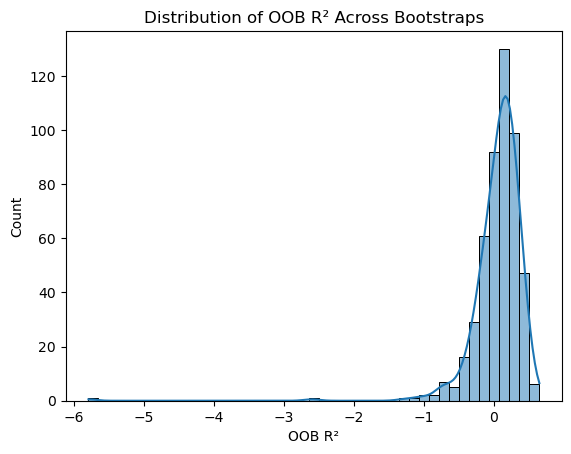

In [23]:
sns.histplot(df_metadata["r2_oob"], kde=True)
plt.xlabel("OOB R²")
plt.title("Distribution of OOB R² Across Bootstraps")
plt.show()

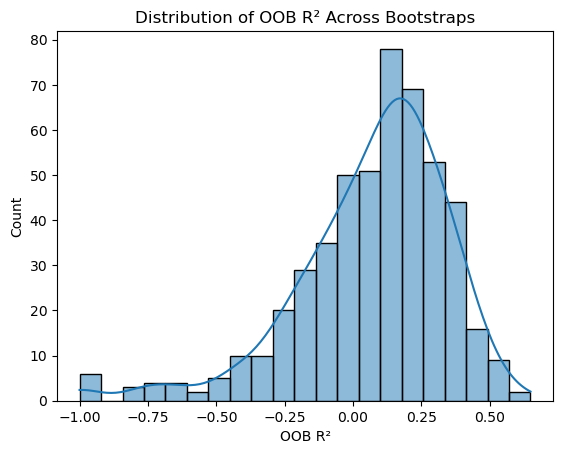

In [24]:
sns.histplot(df_metadata["r2_oob"].clip(-1), kde=True)
plt.xlabel("OOB R²")
plt.title("Distribution of OOB R² Across Bootstraps")
plt.show()

In [25]:
df_metadata.head()

,best_alpha,best_l1_ratio,r2_oob,oob_size
0,0.000263,1.0,-0.143527,19
1,0.030346,0.1,0.177313,19
2,0.157536,0.1,-0.611513,12
3,0.010324,0.1,0.150713,14
4,0.020924,1.0,-0.146697,15


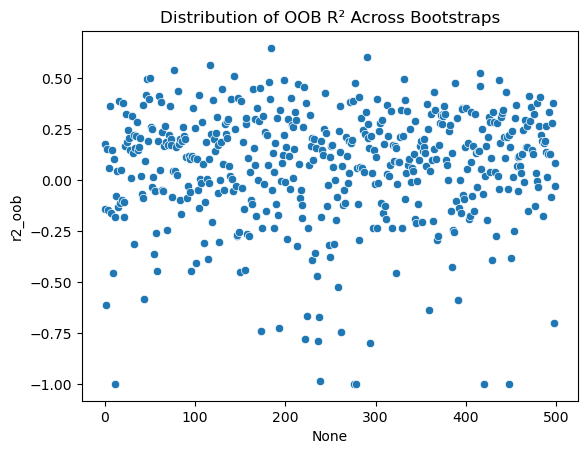

In [26]:
sns.scatterplot(y=df_metadata["r2_oob"].clip(-1), x=df_metadata.index,)

plt.title("Distribution of OOB R² Across Bootstraps")
plt.savefig('oob_r2csore_across_boostraps.pdf')
plt.show()

In [27]:
# Aggregate results
selection_matrix = pd.DataFrame([res[0] for res in results])
gene_selection_freq = selection_matrix.sum(axis=0) / num_bootstraps
gene_selection_freq = gene_selection_freq.sort_values(ascending=False)

In [36]:
# 1) Cumulative selection frequencies after b bootstraps
#    freq_trajectory: shape (num_bootstraps, n_genes)
#cum_counts = selection_matrix.cumsum(axis=0)
bootstrap_metadata = df_metadata.copy()
cum_counts = selection_matrix.cumsum(axis=0)
n = np.arange(1, num_bootstraps + 1)[:, None]  # column vector 1..num_bootstraps
freq_trajectory = cum_counts.div(n)

# 2) Compare each intermediate frequency vector to the final one
final_freq = gene_selection_freq.loc[selection_matrix.columns].values  # ensure same order

# mean absolute difference to final frequencies at each bootstrap b
mean_abs_diff_to_final = (freq_trajectory.values - final_freq).astype(float)
mean_abs_diff_to_final = np.abs(mean_abs_diff_to_final).mean(axis=1)  # length = num_bootstraps

convergence_df = pd.DataFrame({
    "n_bootstraps": np.arange(1, num_bootstraps + 1),
    "mean_abs_diff_to_final": mean_abs_diff_to_final,
})

# 3) (Optional) track convergence of hyperparameters and R²
convergence_df["alpha_mean"] = bootstrap_metadata["best_alpha"].expanding().mean()
convergence_df["l1_ratio_mean"] = bootstrap_metadata["best_l1_ratio"].expanding().mean()
convergence_df["r2_mean"] = bootstrap_metadata["r2_oob"].expanding().mean()

# Save convergence info
#convergence_df.to_csv("elasticnet_bootstrap_convergence_27112025.csv", index=False)

# 4) (Optional) convergence of top-k gene set
k = 30  # for example
topk_final = set(gene_selection_freq.head(k).index)

def overlap_with_final_topk(freqs_row):
    # freqs_row is a pandas Series, selection freq after b bootstraps
    topk_current = set(freqs_row.sort_values(ascending=False).head(k).index)
    return len(topk_current & topk_final) / k

topk_overlap = [
    overlap_with_final_topk(freq_trajectory.iloc[i])
    for i in range(num_bootstraps)
]
convergence_df["top{}_overlap_with_final".format(k)] = topk_overlap

# You can re-save if you add this column after the first save:
convergence_df.to_csv("elasticnet_bootstrap_convergence_22122025.csv", index=False)

In [41]:
convergence_df.head()

,n_bootstraps,mean_abs_diff_to_final,alpha_mean,l1_ratio_mean,r2_mean,top30_overlap_with_final
0,1,0.090436,0.000263,1.000,-0.143527,0.433333
1,2,0.091522,0.015304,0.550,0.016893,0.400000
2,3,0.072324,0.062715,0.400,-0.192576,0.566667
3,4,0.071876,0.049617,0.325,-0.106754,0.500000
4,5,0.061811,0.043879,0.460,-0.114742,0.533333


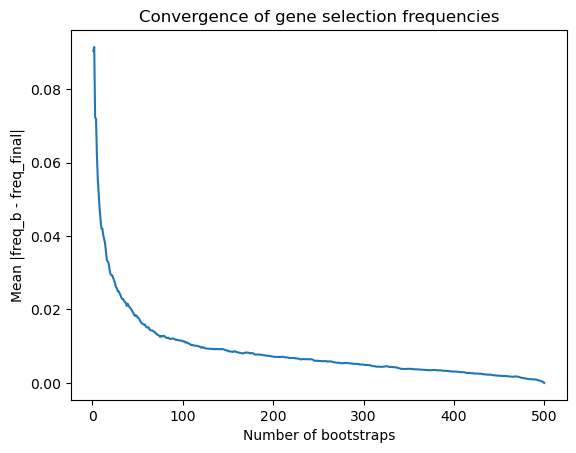

In [35]:

plt.plot(convergence_df["n_bootstraps"], convergence_df["mean_abs_diff_to_final"])
plt.xlabel("Number of bootstraps")
plt.ylabel("Mean |freq_b - freq_final|")
plt.title("Convergence of gene selection frequencies")
#plt.show()
plt.savefig('Model_convergence_22122025.pdf', dpi=300, bbox_inches='tight')

In [30]:
gene_selection_freq.head()

Gene
UBIAD1     0.846
RPS4Y1     0.832
LPAR3      0.800
GAL3ST1    0.788
PSD2       0.722
dtype: float64

In [31]:
df_out = pd.DataFrame(gene_selection_freq)
df_out = df_out.reset_index()

In [32]:
df_out

,Gene,0
0,UBIAD1,0.846
1,RPS4Y1,0.832
2,LPAR3,0.800
3,GAL3ST1,0.788
4,PSD2,0.722
...,...,...
610,STAT5B,0.000
611,ZDHHC18,0.000
612,KAT7,0.000
613,VPS26B,0.000


In [33]:
df_out.columns = ['Gene', 'Value']
df_out.index = df_out.Gene

In [34]:
df_out.head()

,Gene,Value
Gene,,
UBIAD1,UBIAD1,0.846
RPS4Y1,RPS4Y1,0.832
LPAR3,LPAR3,0.800
GAL3ST1,GAL3ST1,0.788
PSD2,PSD2,0.722


In [37]:
df_out.to_csv('elasticnet_parallel_bootstrap_results_22122025.csv')

/scratch/trulss0000/slurm-job.65601566/ipykernel_2137184/4155042176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_out['Value'][:20] *100, y=df_out.index[:20], palette="viridis")


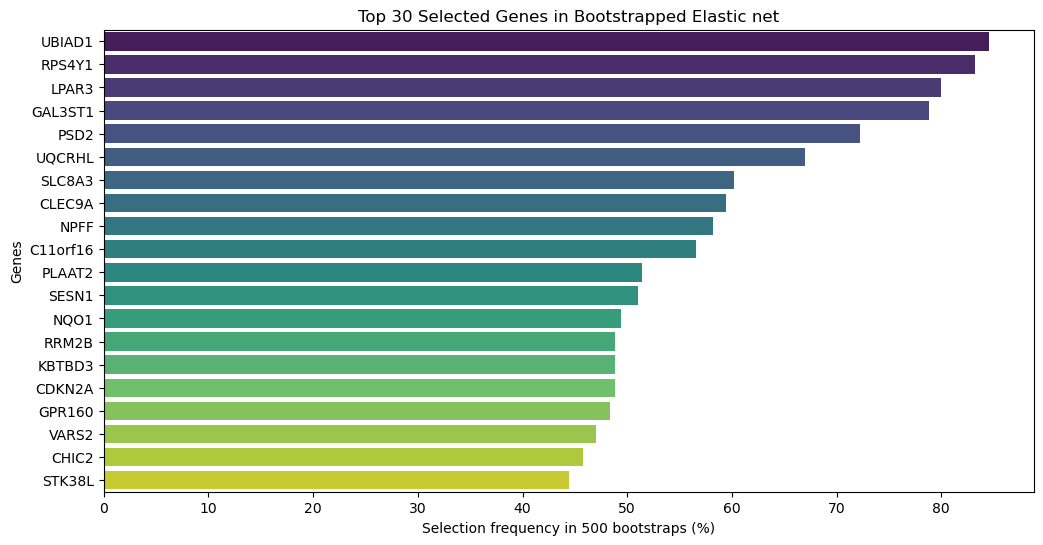

In [38]:
# Plot the selection frequency of genes
plt.figure(figsize=(12, 6))
sns.barplot(x=df_out['Value'][:20] *100, y=df_out.index[:20], palette="viridis")
plt.xlabel("Selection frequency in 500 bootstraps (%)")
plt.ylabel("Genes")
plt.title("Top 30 Selected Genes in Bootstrapped Elastic net")
plt.savefig('Bootstrapped_elasticnet_predict_hcc_221225.pdf', bbox_inches='tight', dpi=300)